# **Supervised Algorithms**  

This notebook demonstrates three fundamental machine learning algorithms:  

1. Linear Regression  
2. Logistic Regression  
3. Decision Trees  

We'll use popular Python libraries like **scikit-learn**, **numpy**, and **matplotlib** to explore these algorithms.

In [139]:
# Import necessary libraries
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.tree import DecisionTreeClassifier

from sklearn.datasets import make_regression, make_classification
from sklearn.metrics import mean_squared_error, accuracy_score, classification_report,r2_score 

## 1. Linear Regression

Linear Regression is used to predict a continuous output based on input features. It finds the best linear relationship between inputs and outputs by minimizing the squared differences between predicted and actual values.

In [140]:
# Generate synthetic regression data
X, y = make_regression(n_samples=100, n_features=1, noise=10, random_state=42)

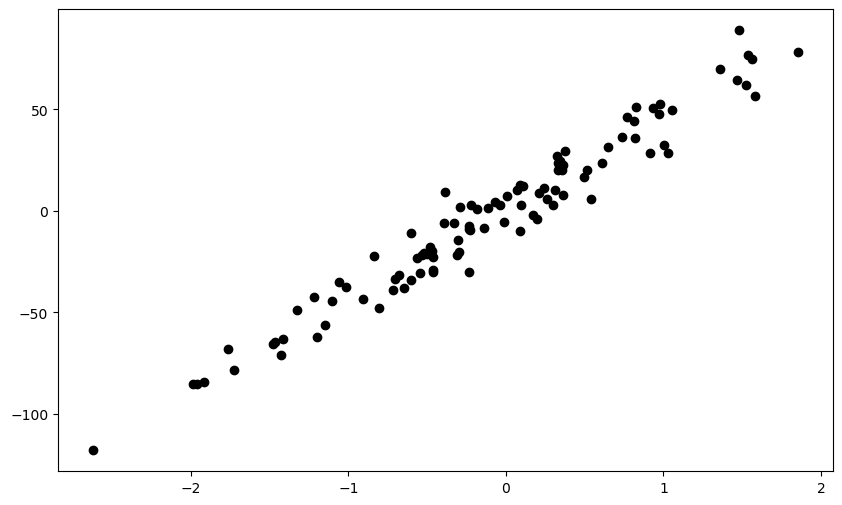

In [141]:
plt.figure(figsize=(10,6))
plt.scatter(X, y, color='black')
plt.show()

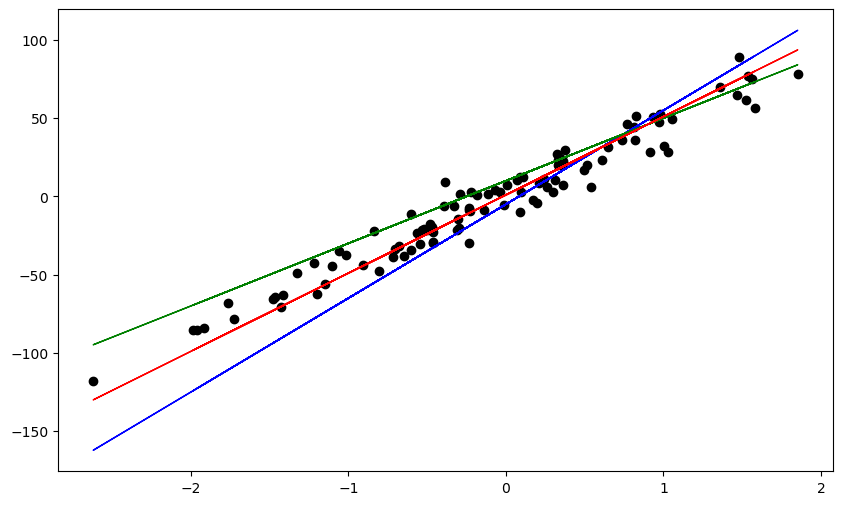

In [142]:
plt.figure(figsize=(10,6))
plt.scatter(X, y, color='black')
plt.plot(X, 60 * X - 5, color='blue', linewidth=1)
plt.plot(X, 40 * X + 10, color='green', linewidth=1)
plt.plot(X, 50 * X + 1, color='red', linewidth=1)
plt.show()

In [143]:
# Split data
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42)

In [144]:
# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)  # fit e transform sui dati di training
X_test_scaled = scaler.transform(X_test)  # solo transform sui dati di test

In [145]:
# Train Linear Regression model
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)

LinearRegression()

In [146]:
# Predict and evaluate
y_pred = lr_model.predict(X_test_scaled)
mse = mean_squared_error(y_test, y_pred)
print(f"Mean Squared error: {mse:.2f}")

Mean Squared error: 104.20


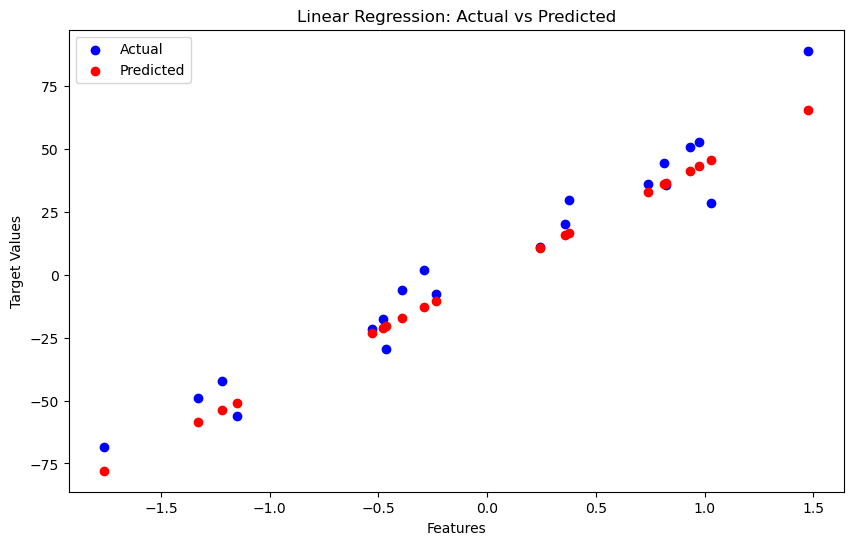

In [147]:
# Visualizzation
plt.figure(figsize=(10, 6))
plt.scatter(X_test, y_test, color='blue', label='Actual')
plt.scatter(X_test, y_pred, color='red', label='Predicted')
plt.title('Linear Regression: Actual vs Predicted')
plt.xlabel('Features')
plt.ylabel('Target Values')
plt.legend() 
plt.show()

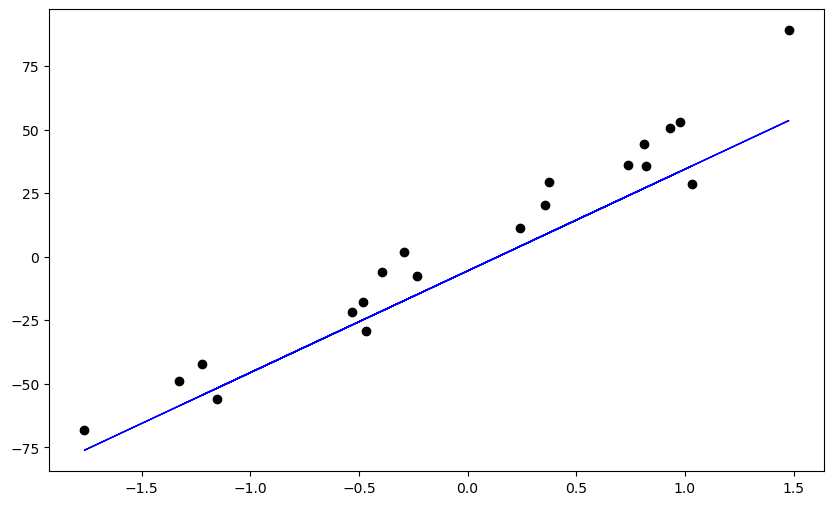

In [148]:
# Get the coefficients
slope = lr_model.coef_[0] # Coefficient (b0)
intercept = lr_model.intercept_
# Intercept (bl)
plt.figure(figsize=(10, 6))
plt.scatter(X_test, y_test, color='black')
plt.plot(X_test, slope * X_test + intercept, color='blue', linewidth=1)
plt.show()

In [149]:
slope, intercept

(40.010918477445315, -5.59298838409338)

# 2. Logistic Regression

Logistic Regression is used for binary classification problems. Despite its name, it's a classification algorithm that uses the logistic function to predict probability of an instance belonging to a particular class.

In [175]:
# Generate synthetic classification data
X, y = make_classification(n_samples=200, n_features=2, n_informative=2, n_redundant=0, random_state=42)

In [176]:
X

array([[ 1.68976749e+00, -1.40824123e+00],
       [ 1.53028665e+00, -1.45984815e+00],
       [-1.17504152e+00, -1.44763291e+00],
       [-2.58539507e+00,  9.63532238e-01],
       [ 1.37224580e+00,  4.40695372e-01],
       [ 7.31936138e-01,  8.49752970e-01],
       [-2.10684207e+00, -1.56005160e-01],
       [-9.36016045e-01,  5.43282487e-01],
       [-1.64699537e+00,  4.93409195e-01],
       [ 4.25361481e-01,  2.41426917e-01],
       [ 8.55819924e-01, -4.30645568e-01],
       [ 1.67660005e+00, -1.71348441e+00],
       [-2.06987792e+00,  2.52602241e-01],
       [-7.95777151e-01,  4.93854713e-02],
       [ 1.77079592e+00,  1.53557656e+00],
       [ 3.65788291e-01,  2.23297154e+00],
       [-5.27587135e-02, -2.18236826e+00],
       [ 5.74030019e-01,  4.47236811e-01],
       [-1.06467498e+00, -7.52371616e-01],
       [ 2.24658823e+00, -1.51455024e+00],
       [-6.28449323e-01, -2.07252229e-01],
       [-1.75906144e+00,  7.58449497e-01],
       [-1.15587568e+00, -1.94994197e+00],
       [ 8.

In [177]:
y

array([1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0,
       0, 1, 0, 1, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0,
       0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1,
       0, 0, 1, 1, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0,
       1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 0,
       0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0,
       1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 1,
       1, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 0,
       1, 1, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 1, 0, 1, 1, 0, 1, 0,
       1, 0])

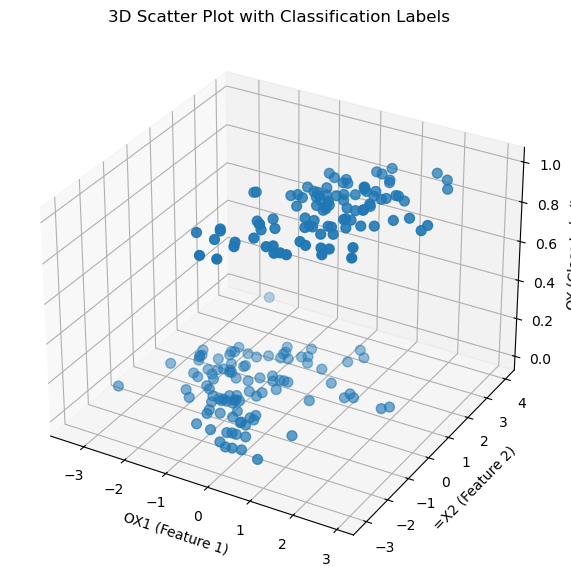

In [178]:
# Create a 3D plot
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

# Scatter plot with class-based coloring
ax.scatter(X[:, 0], X[:, 1], y, s=50)

# Labels and title
ax.set_xlabel("OX1 (Feature 1)")
ax.set_ylabel("=X2 (Feature 2)")
ax.set_zlabel("OY (Class Label)")
ax.set_title("3D Scatter Plot with Classification Labels")
plt.show()

In [179]:
# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [180]:
# Standard scaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)  # fit e transform sui dati di training
X_test_scaled = scaler.transform(X_test)  # solo transform sui dati di test

In [181]:
min(X_train[:,0]), max(X_train[:,0])

(-3.365582304231961, 2.9172517291252813)

In [182]:
min(X_train_scaled[:,0]), max(X_train_scaled[:,0])

(-2.5315846224711676, 2.2121724519326857)

In [183]:
# Train logistic regression model
log_model = LogisticRegression()

log_model.fit(X_train_scaled, y_train)

LogisticRegression()

In [184]:
# Predict and evaluate
y_pred = log_model.predict(X_test_scaled)
accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy: {accuracy: .2f}")
print("Classification Report:")
print(classification_report(y_test,y_pred))

Accuracy:  0.80
Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.74      0.78        19
           1       0.78      0.86      0.82        21

    accuracy                           0.80        40
   macro avg       0.80      0.80      0.80        40
weighted avg       0.80      0.80      0.80        40



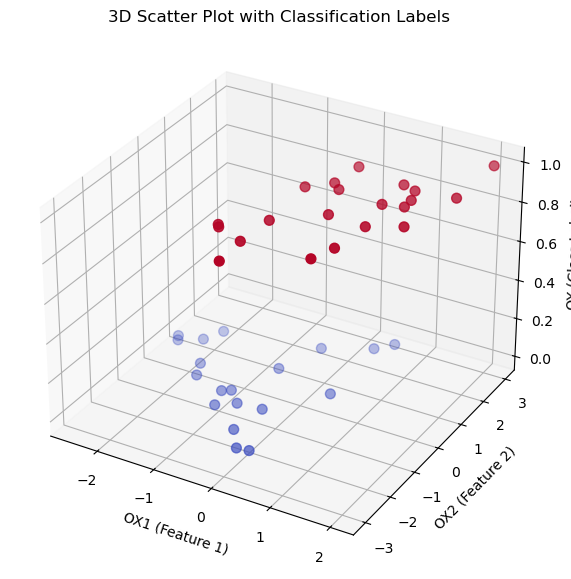

In [185]:
# Create a 3D plot
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

# Scatter plot with class-based coloring
ax.scatter(X_test[:, 0], X_test[:, 1], y_test, s=50, c=y_test, cmap='coolwarm')

# Labels and title
ax.set_xlabel("OX1 (Feature 1)")
ax.set_ylabel("OX2 (Feature 2)")
ax.set_zlabel("OY (Class Label)")
ax.set_title("3D Scatter Plot with Classification Labels")

plt.show()

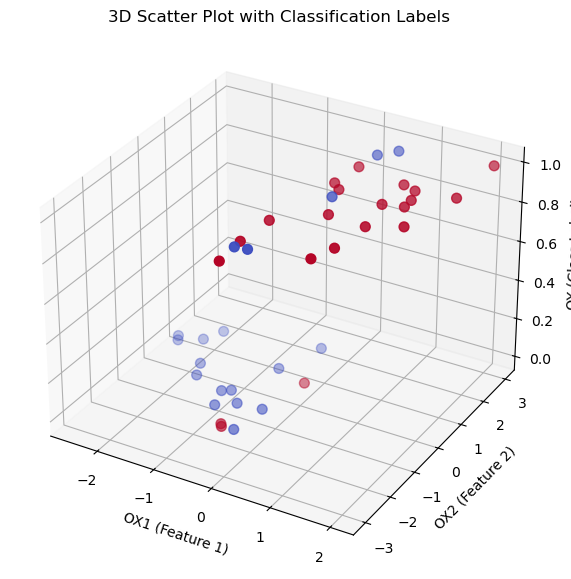

In [161]:
# Create a 3d Plot
fig = plt.figure(figsize=(10,7))
ax = fig.add_subplot(111, projection='3d')

# Scatter plot with class-based coloring
ax.scatter(X_test[:,0], X_test[:,1], y_pred, s=50, c=y_test, cmap='coolwarm')

# Labels and title
ax.set_xlabel("OX1 (Feature 1)")
ax.set_ylabel("OX2 (Feature 2)")
ax.set_zlabel("OY (Class Label)")
ax.set_title("3D Scatter Plot with Classification Labels")

plt.show()

# 3. Decision Trees

Decision Trees are versatile machine learning algorithms that can be used for both classification and regression. They work by creating a tree-like model of decisions based on feature values, making them highly interpretable.

## Iris Species Classification

In [162]:
from sklearn.datasets import load_iris
from sklearn.tree import plot_tree

In [163]:
# Load iris dataset

iris = load_iris()
X,y = iris.data, iris.target

In [164]:
# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [165]:
len(X_train), len(X_test), len(y_train), len(y_test)

(120, 30, 120, 30)

In [166]:
# Train decision tree model

tree_model = DecisionTreeClassifier(max_depth=3, random_state=42) # max_depth a sentimento, facendo varie prove
tree_model.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=3, random_state=42)

In [167]:
# Predict and evaluate

y_pred = tree_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)


print(f"Accuracy: {accuracy:.2f}")
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=iris.target_names))

Accuracy: 1.00
Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



In [97]:
parameters = [1,2,3,4,5]

In [99]:
for parameter in parameters:
    tree_model = DecisionTreeClassifier(max_depth=parameter, random_state=42)
    tree_model.fit(X_train,y_train)
    y_pred = tree_model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)

    print(f"Accuracy : {accuracy:.2f} for paparameter: {parameter}")

Accuracy : 0.63 for paparameter: 1
Accuracy : 0.97 for paparameter: 2
Accuracy : 1.00 for paparameter: 3
Accuracy : 1.00 for paparameter: 4
Accuracy : 1.00 for paparameter: 5


In [101]:
iris.feature_names, iris.target_names

(['sepal length (cm)',
  'sepal width (cm)',
  'petal length (cm)',
  'petal width (cm)'],
 array(['setosa', 'versicolor', 'virginica'], dtype='<U10'))

In [109]:
## 2 split e 3 livelli

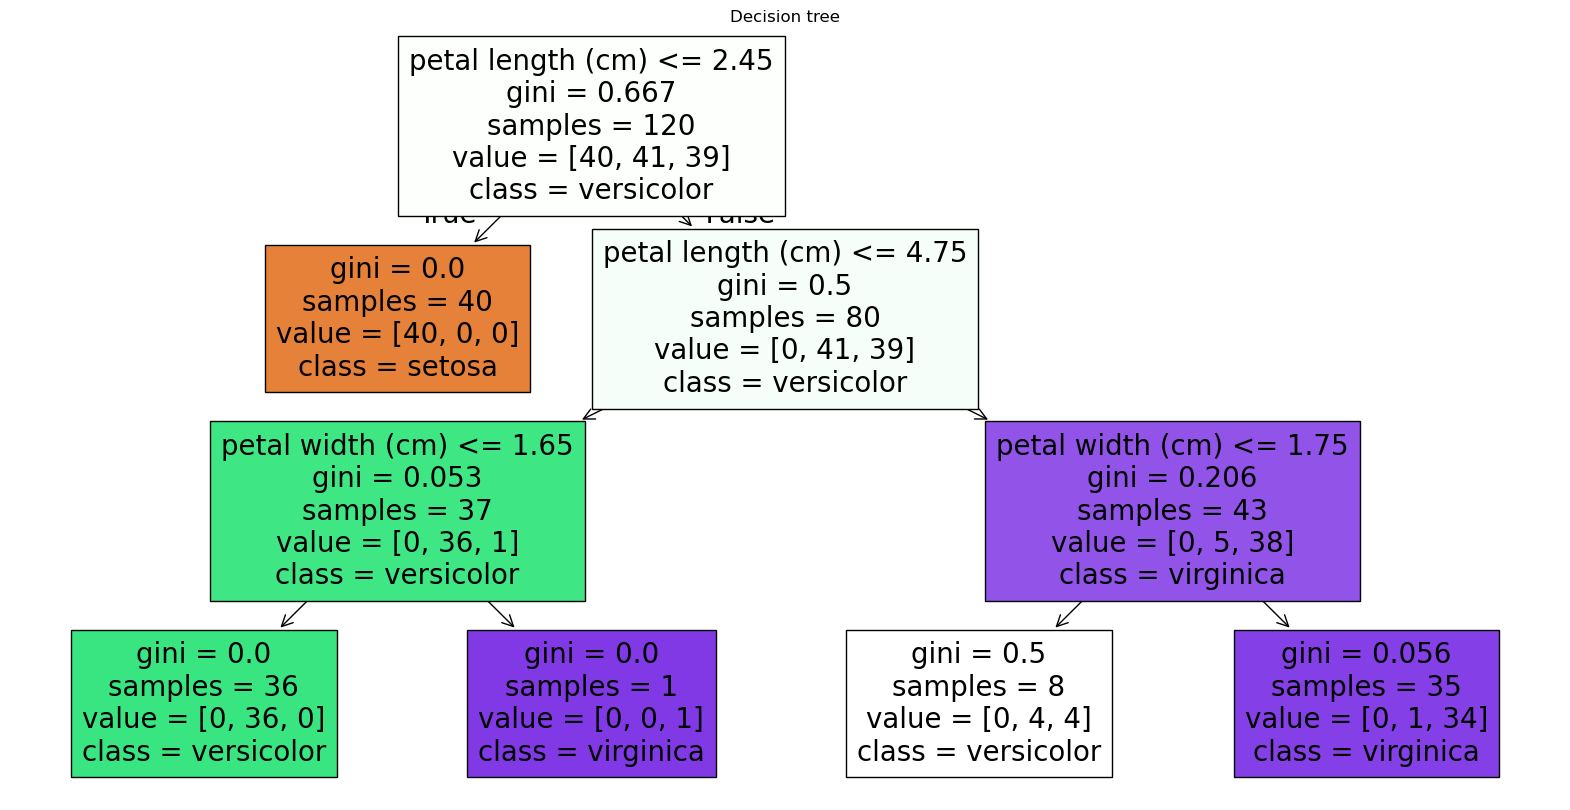

In [168]:
# Visualization of Decision Tree
plt.figure(figsize=(20,10))
plot_tree(tree_model, feature_names=iris.feature_names, class_names=iris.target_names, filled=True)
plt.title("Decision tree")
plt.show()

## Decision tree regression

In [110]:
from sklearn.tree import DecisionTreeRegressor

In [113]:
X, y = make_regression(n_samples=100, n_features=1, noise=8, random_state=12)

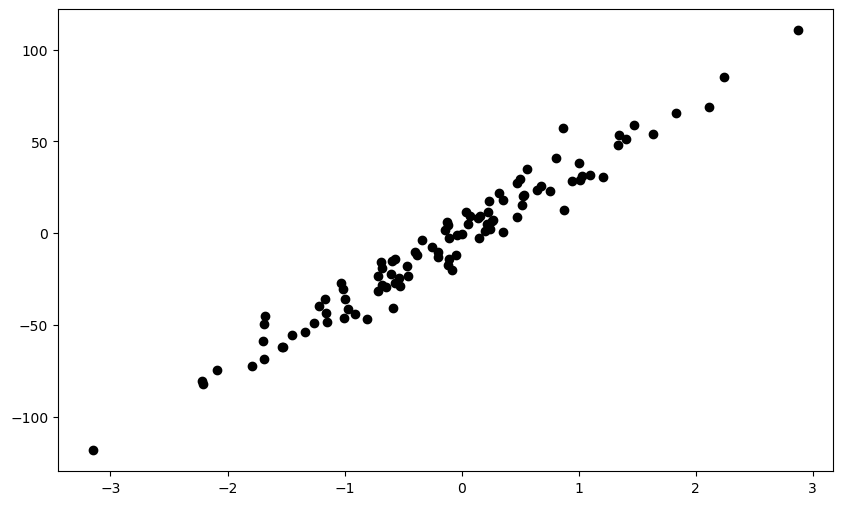

In [114]:
plt.figure(figsize=(10,6))
plt.scatter(X, y, color='black')
plt.show()

In [115]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [118]:
# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)  # fit e transform sui dati di training
X_test_scaled = scaler.transform(X_test)  # solo transform sui dati di test

In [119]:
dt_model = DecisionTreeRegressor(max_depth=3, random_state=42)

In [121]:
dt_model.fit(X_train_scaled, y_train)

DecisionTreeRegressor(max_depth=3, random_state=42)

In [126]:
# Predict and evaluate
y_pred = dt_model.predict(X_test_scaled)

In [127]:
mean_squared_error(y_test, y_pred)

237.75839872838452

In [131]:
r2_score(y_test, y_pred)

0.8537229947477192

### Andiamo bene con i valori alti peggio con quelli bassi
Vediamo che non sono più su una linea ma raggruppati in piccole classi di decision tree

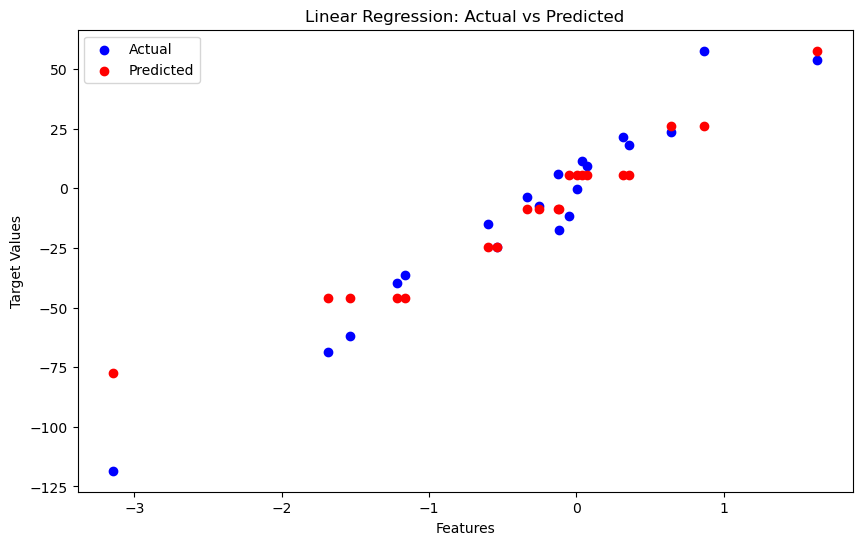

In [132]:
# Visualizzation
plt.figure(figsize=(10, 6))
plt.scatter(X_test, y_test, color='blue', label='Actual')
plt.scatter(X_test, y_pred, color='red', label='Predicted')
plt.title('Decision Tree: Actual vs Predicted')
plt.xlabel('Features')
plt.ylabel('Target Values')
plt.legend() 
plt.show()

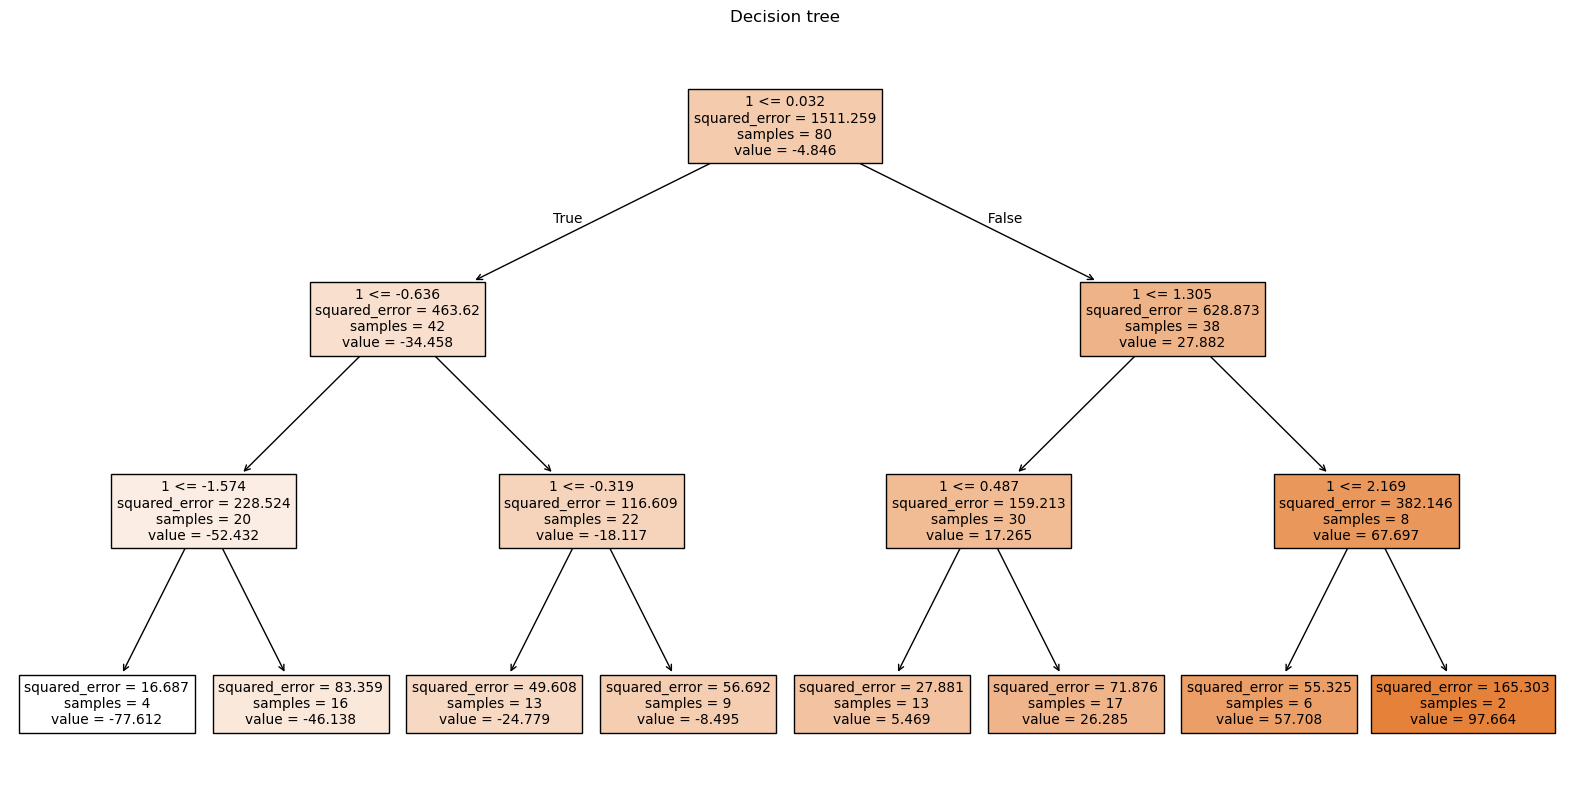

In [136]:
# Visualization of Decision Tree

plt.figure(figsize=(20,10))
plot_tree(dt_model, feature_names=["1"], filled=True)
plt.title("Decision tree")
plt.show()